
Tren Meckel <br>
Dr. Truex<br>
CS 323: Data Privacy<br>
20 October 2025<br>
###### happy birthday me!!


# Project 4: Differential Privacy
###### Introduces the experiment and its overall goal.
###### This project extends Project 3 by adding a Differential Privacy (DP) mechanism.
###### Four approaches are compared for computing an average across `n` parties:
###### 1. Non-private (baseline)
###### 2. Paillier encryption (additively homomorphic)
###### 3. Shamir’s Secret Sharing (threshold-based SMPC)
###### 4. Differential Privacy (Laplace mechanism with ε = 1.0)
###### Results will include both runtime and accuracy comparisons, saved as plots and CSVs.


## Import Statements

In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt
from phe import paillier
import random
import csv
import os

## Settings

###### Defines key experiment parameters used throughout the project:
###### - `n_values`: list of party counts to test (e.g., [10, 50, 100, 500, 1000]).
###### - `low`, `high`: bounds for randomly generated integer values.
###### - `epsilon_dp`: privacy budget for the differential privacy mechanism (default = 1.0).
###### - `dp_repeats`: how many times to repeat each DP experiment (since DP adds noise).
###### - `PRIME`: large modulus used in Shamir’s scheme.
###### - `out_dir`: folder where all generated CSVs and plots will be saved.
###### Changing these parameters allows exploring different scales and privacy settings.

In [6]:
n_values = [10, 50, 100, 250, 500]   # number of parties / inputs to test
low, high = 1, 100                   # data domain (integers)
epsilon_dp = 1.0                     # DP privacy budget
dp_repeats = 30                      # number of DP repeats for averaging error & runtime
PRIME = 2**2048 - 189                # Shamir modulus (same as Project3)

out_dir = "project4_outputs"
os.makedirs(out_dir, exist_ok=True)

### Helper Functions (Project 3 Base)
#### -------------------------------------------------------------------
###### Contains core helper functions used across all methods.
###### - `generate_values(n, low, high)`: Generates `n` random integers.
###### - `time_function(func, *args)`: Measures runtime for a given function call.
###### These helpers keep the experiment consistent and make code cleaner.

In [8]:
# ----------------------------
# Helpers (from corrected Project3)
# ----------------------------
def generate_values(n, low=1, high=100):
    return np.random.randint(low, high + 1, size=n)

# Non-private baseline
def compute_average_non_private(values):
    start = time.time()
    avg = np.mean(values)
    end = time.time()
    return avg, end - start

# Paillier with phase timings (setup vs compute)
def compute_average_paillier(values):
    t0 = time.time()
    public_key, private_key = paillier.generate_paillier_keypair()
    t_keygen = time.time() - t0

    t1 = time.time()
    encrypted_values = [public_key.encrypt(int(v)) for v in values]
    encrypted_sum = sum(encrypted_values)
    avg = private_key.decrypt(encrypted_sum) / len(values)
    t_compute = time.time() - t1

    total = t_keygen + t_compute
    return avg, total, t_keygen, t_compute

# Shamir split/reconstruct (unchanged)
def shamir_split(secret, total_parties, threshold, prime=PRIME):
    coeffs = [secret] + [random.randint(0, prime - 1) for _ in range(threshold - 1)]
    shares = []
    for x in range(1, total_parties + 1):
        y = sum([coeffs[i] * pow(x, i, prime) for i in range(threshold)]) % prime
        shares.append((x, y))
    return shares

def shamir_reconstruct(shares, threshold, prime=PRIME):
    selected = shares[:threshold]
    x_s, y_s = zip(*selected)
    secret = 0
    for j in range(threshold):
        num = 1
        den = 1
        for m in range(threshold):
            if m != j:
                num = (num * (-x_s[m])) % prime
                den = (den * (x_s[j] - x_s[m])) % prime
        lagrange = num * pow(den, -1, prime)
        secret = (secret + y_s[j] * lagrange) % prime
    return secret

def compute_average_shamir(values, total_parties, threshold, prime=PRIME):
    # Setup (split shares)
    t0 = time.time()
    all_shares = [shamir_split(int(v), total_parties, threshold, prime) for v in values]
    t_setup = time.time() - t0

    # Compute (local sums + reconstruct)
    t1 = time.time()
    party_sums = []
    for i in range(total_parties):
        # sum y-values for party i over all secrets
        party_sum = sum([shares[i][1] for shares in all_shares]) % prime
        party_sums.append((i + 1, party_sum))
    total_sum = shamir_reconstruct(party_sums[:threshold], threshold, prime)
    avg = total_sum / len(values)
    t_compute = time.time() - t1

    total = t_setup + t_compute
    return avg, total, t_setup, t_compute


###  Non-Private Computation
#### -------------------------------------------------------------------
###### Computes the simple (non-private) average of all generated values.
###### Used as a baseline for both runtime and accuracy comparisons.
###### No encryption, secret sharing, or noise is used here.

In [10]:
# Differential privacy (Laplace) for average
def compute_average_dp(values, epsilon=1.0, low=1, high=100):
    """
    Computes DP average by adding Laplace noise to the true average.
    Sensitivity of average = (high - low) / n (neighbors differ by at most that).
    """
    n = len(values)
    true_avg = np.mean(values)
    sensitivity = (high - low) / n
    b = sensitivity / epsilon  # Laplace scale
    t0 = time.time()
    noise = np.random.laplace(loc=0.0, scale=b)
    dp_avg = true_avg + noise
    t1 = time.time()
    return dp_avg, t1 - t0  # runtime only for adding noise (no setup)

## Run Experiments Across All Methods
#### -------------------------------------------------------------------
###### Runs all four methods (Non-private, Paillier, Shamir, DP) for each `n` value.
###### Each run records two key metrics:
###### 1. Runtime — total time for setup and computation.
###### 2. Accuracy — deviation from the true mean (absolute error).
###### The same random data is used across all methods for fairness.
###### Results are stored in Python lists and later exported as CSVs.

In [12]:
# ----------------------------
# Experiment loop: runtime + accuracy
# ----------------------------
# store detailed results for plotting and CSV export.
results = []  # list of dict rows

# For DP we will compute mean & std of runtime and abs error across dp_repeats
for n in n_values:
    print(f"Running n = {n} ...")
    threshold = n // 2
    values = generate_values(n, low=low, high=high)
    true_avg, t_non = compute_average_non_private(values)

    # Paillier
    avg_p, total_p, setup_p, compute_p = compute_average_paillier(values)
    err_p = abs(avg_p - true_avg)  # should be ~0

    # Shamir (now uses same 'values')
    avg_s, total_s, setup_s, compute_s = compute_average_shamir(values, n, threshold)
    err_s = abs(avg_s - true_avg)  # should be ~0 (mod prime wrap-around not expected here)

    # Differential privacy: repeat because randomized
    dp_runtimes = []
    dp_errors = []
    for _ in range(dp_repeats):
        dp_avg, dp_t = compute_average_dp(values, epsilon=epsilon_dp, low=low, high=high)
        dp_runtimes.append(dp_t)
        dp_errors.append(abs(dp_avg - true_avg))

    dp_runtime_mean = float(np.mean(dp_runtimes))
    dp_runtime_std = float(np.std(dp_runtimes, ddof=1)) if dp_repeats > 1 else 0.0
    dp_error_mean = float(np.mean(dp_errors))
    dp_error_std = float(np.std(dp_errors, ddof=1)) if dp_repeats > 1 else 0.0

    # Store a single row summarizing this n
    row = {
        "n": n,
        "true_avg": float(true_avg),
        "non_private_time": float(t_non),
        "paillier_total": float(total_p),
        "paillier_setup": float(setup_p),
        "paillier_compute": float(compute_p),
        "paillier_error": float(err_p),
        "shamir_total": float(total_s),
        "shamir_setup": float(setup_s),
        "shamir_compute": float(compute_s),
        "shamir_error": float(err_s),
        "dp_eps": float(epsilon_dp),
        "dp_runtime_mean": dp_runtime_mean,
        "dp_runtime_std": dp_runtime_std,
        "dp_error_mean": dp_error_mean,
        "dp_error_std": dp_error_std,
        "dp_repeats": dp_repeats
    }
    results.append(row)

    print(f" n={n}: non={t_non:.6f}s, paillier={total_p:.4f}s (setup {setup_p:.4f}, compute {compute_p:.4f}),"
          f" shamir={total_s:.4f}s (setup {setup_s:.4f}, compute {compute_s:.4f}),"
          f" dp_err={dp_error_mean:.4f}±{dp_error_std:.4f}, dp_time={dp_runtime_mean:.6f}s")


Running n = 10 ...
 n=10: non=0.000069s, paillier=9.6083s (setup 6.7548, compute 2.8535), shamir=0.0004s (setup 0.0003, compute 0.0001), dp_err=12.1456±10.8220, dp_time=0.000003s
Running n = 50 ...
 n=50: non=0.000035s, paillier=17.8746s (setup 3.0373, compute 14.8373), shamir=0.0360s (setup 0.0346, compute 0.0014), dp_err=1.8532±1.7035, dp_time=0.000002s
Running n = 100 ...
 n=100: non=0.000033s, paillier=34.6688s (setup 8.0589, compute 26.6099), shamir=0.4039s (setup 0.3969, compute 0.0070), dp_err=1.0402±0.9947, dp_time=0.000002s
Running n = 250 ...
 n=250: non=0.000034s, paillier=67.8368s (setup 2.0350, compute 65.8019), shamir=13.2389s (setup 13.1999, compute 0.0389), dp_err=0.4642±0.3632, dp_time=0.000002s
Running n = 500 ...
 n=500: non=0.000033s, paillier=135.4118s (setup 2.9893, compute 132.4225), shamir=210.7046s (setup 210.5099, compute 0.1947), dp_err=0.2379±0.2152, dp_time=0.000002s


## Save Results and Generate Plots
#### -------------------------------------------------------------------
###### Saves runtime and accuracy data to CSV files for reproducibility.
###### Generates two key plots:
###### 1. Runtime vs. Number of Parties (`n`)
###### 2. Accuracy (Absolute Error) vs. Number of Parties (`n`)
###### These plots visually highlight trade-offs between performance and privacy.
###### Final results are exported as `.png` files inside the results directory.

Saved results to project4_outputs/results_dp.csv


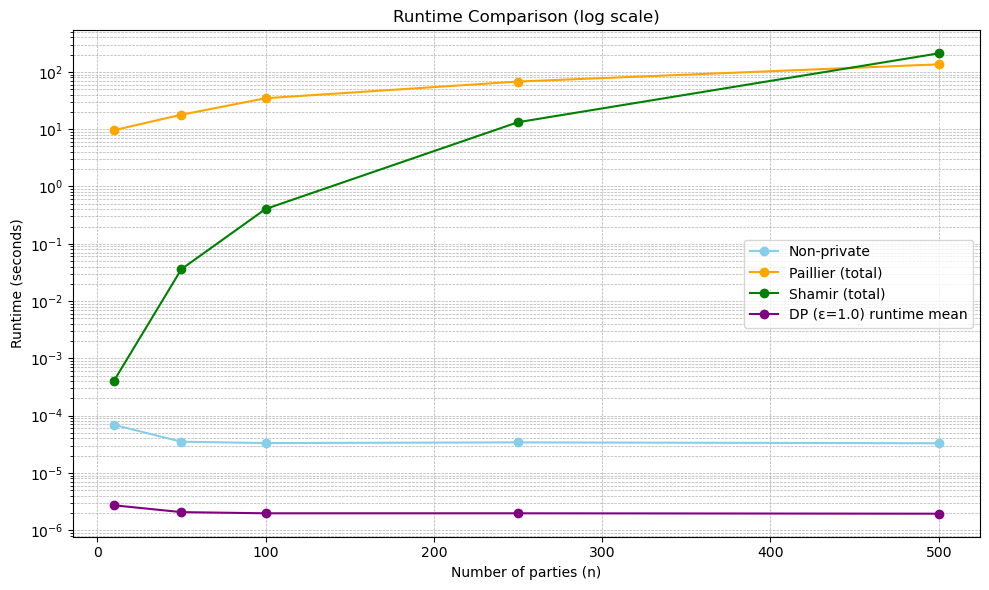

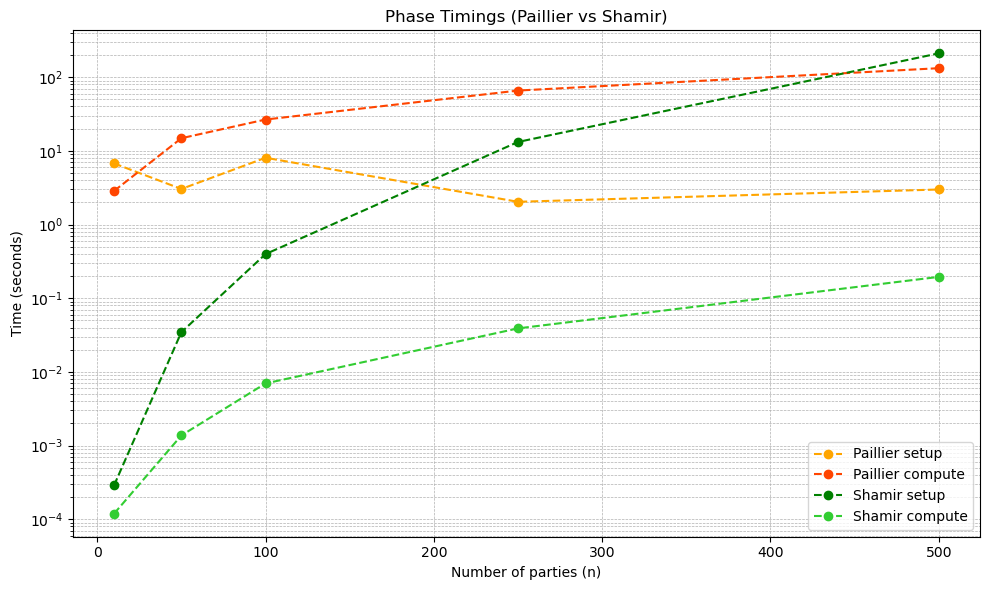

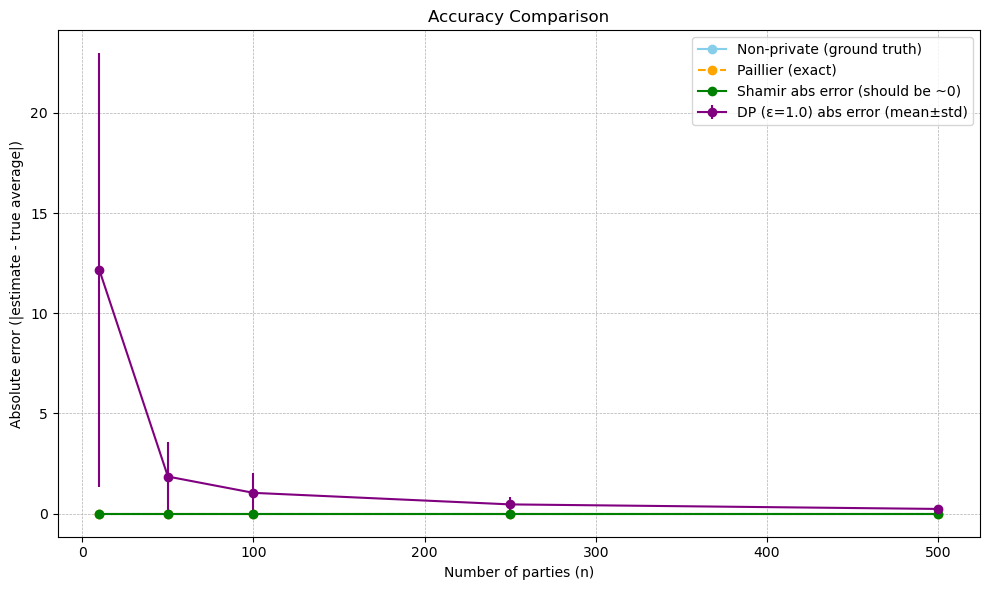

All plots saved to: project4_outputs


In [14]:
# ----------------------------
# Save results CSV
# ----------------------------
csv_path = os.path.join(out_dir, "results_dp.csv")
fieldnames = list(results[0].keys())
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in results:
        writer.writerow(r)
print(f"Saved results to {csv_path}")

# ----------------------------
# Plotting: runtime and accuracy
# ----------------------------
# Convert results columns to arrays for plotting
ns = [r["n"] for r in results]
rp_non = [r["non_private_time"] for r in results]
rp_p = [r["paillier_total"] for r in results]
rp_s = [r["shamir_total"] for r in results]
rp_p_setup = [r["paillier_setup"] for r in results]
rp_p_compute = [r["paillier_compute"] for r in results]
rp_s_setup = [r["shamir_setup"] for r in results]
rp_s_compute = [r["shamir_compute"] for r in results]
dp_rt_mean = [r["dp_runtime_mean"] for r in results]
dp_err_mean = [r["dp_error_mean"] for r in results]
dp_err_std = [r["dp_error_std"] for r in results]

# 1) Runtime comparison (log)
plt.figure(figsize=(10,6))
plt.plot(ns, rp_non, 'o-', label="Non-private", color='skyblue')
plt.plot(ns, rp_p, 'o-', label="Paillier (total)", color='orange')
plt.plot(ns, rp_s, 'o-', label="Shamir (total)", color='green')
plt.plot(ns, dp_rt_mean, 'o-', label=f"DP (ε={epsilon_dp}) runtime mean", color='purple')
plt.xlabel("Number of parties (n)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison (log scale)")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "runtime_comparison_log.png"), dpi=300)
plt.savefig(os.path.join(out_dir, "runtime_comparison_log.pdf"), dpi=300)
plt.show()

# 2) Phase breakdown (Paillier vs Shamir)
plt.figure(figsize=(10,6))
plt.plot(ns, rp_p_setup, 'o--', label="Paillier setup", color='orange')
plt.plot(ns, rp_p_compute, 'o--', label="Paillier compute", color='orangered')
plt.plot(ns, rp_s_setup, 'o--', label="Shamir setup", color='green')
plt.plot(ns, rp_s_compute, 'o--', label="Shamir compute", color='limegreen')
plt.xlabel("Number of parties (n)")
plt.ylabel("Time (seconds)")
plt.title("Phase Timings (Paillier vs Shamir)")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "phase_comparison.pdf"), dpi=300)
plt.show()

# 3) Accuracy comparison (absolute error)
plt.figure(figsize=(10,6))
plt.plot(ns, [0.0]*len(ns), 'o-', color='skyblue', label="Non-private (ground truth)")
plt.plot(ns, [0.0]*len(ns), 'o--', color='orange', label="Paillier (exact)")
plt.errorbar(ns, dp_err_mean, yerr=dp_err_std, fmt='o-', color='purple', label=f"DP (ε={epsilon_dp}) abs error (mean±std)")
plt.plot(ns, [r["shamir_error"] for r in results], 'o-', color='green', label="Shamir abs error (should be ~0)")
plt.xlabel("Number of parties (n)")
plt.ylabel("Absolute error (|estimate - true average|)")
plt.title("Accuracy Comparison")
plt.legend()
plt.grid(True, ls="--", lw=0.5)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "accuracy_comparison.png"), dpi=300)
plt.savefig(os.path.join(out_dir, "accuracy_comparison.pdf"), dpi=300)
plt.show()

print("All plots saved to:", out_dir)